# Part 1c: Energy Performance Certificate audit (Oxfordshire, 2015–2025)

Audit of the domestic EPC extract: choosing 28 of 93 columns to keep, then checking floor areas, room counts, floor heights, nulls, duplicate certificates per property and dates.

Findings and decisions: `logs/part_1_structural_anomalies.md`

In [295]:
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns

df_raw = pd.read_csv('../data/raw/EDC_OXFORDSHIRE_2015_2025.csv')

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
pd.set_option('display.expand_frame_repr', False)

In [296]:
print(df_raw.columns)
print(df_raw.shape)

Index(['certificate_number', 'address1', 'address2', 'address3', 'postcode', 'posttown', 'address', 'constituency', 'constituency_label', 'local_authority', 'local_authority_label', 'built_form', 'co2_emiss_curr_per_floor_area', 'co2_emissions_current', 'co2_emissions_potential', 'construction_age_band', 'current_energy_efficiency', 'current_energy_rating', 'energy_consumption_current', 'energy_consumption_potential', 'energy_tariff', 'environment_impact_current', 'environment_impact_potential', 'extension_count', 'fixed_lighting_outlets_count', 'flat_storey_count', 'flat_top_storey', 'floor_description', 'floor_energy_eff', 'floor_height', 'floor_level', 'glazed_area', 'glazed_type', 'heat_loss_corridor', 'heating_cost_current', 'heating_cost_potential', 'hot_water_cost_current', 'hot_water_cost_potential', 'hot_water_energy_eff', 'hot_water_env_eff', 'hotwater_description', 'inspection_date', 'lighting_cost_current', 'lighting_cost_potential', 'lighting_description',
       'lighting

### Which columns to keep?

In [297]:
df_raw.isna().sum()

certificate_number         0
address1                   0
address2               98522
address3              188750
postcode                   0
                       ...  
floor_env_eff         172888
region                     0
country                    0
uprn                    1318
uprn_source             1318
Length: 93, dtype: int64

In [298]:
cols = ['local_authority', 'constituency', 'constituency_label', 'region', 'country']

print(df_raw[cols].nunique())
print(df_raw['local_authority'].value_counts())
print(df_raw['constituency'].value_counts())
print(df_raw['constituency_label'].value_counts())
print(df_raw['region'].value_counts())

local_authority       6
constituency          8
constituency_label    7
region                2
country               1
dtype: int64
local_authority
E07000177    47544
E07000178    45721
E07000180    45639
E07000179    42271
E07000181    34875
E07000221        4
Name: count, dtype: int64
constituency
E14001419    34442
E14001197    34268
E14001591    31578
E14001072    30588
E14001420    29442
E14001090    29342
E14001280    26390
E14001526        4
Name: count, dtype: int64
constituency_label
Oxford East                 34442
Didcot and Wantage          34268
Witney                      31579
Banbury                     30592
Oxford West and Abingdon    29441
Bicester and Woodstock      29342
Henley and Thame            26390
Name: count, dtype: int64
region
E12000008    216050
E12000005         4
Name: count, dtype: int64


- Country can be dropped (1 val)
- region can be dropped (only 4 in a second value)
- constituency shows parliamentary constituencies that cut accross boundaries (drop)
- local authority lines up with district in the price paid set
What are the 4 rows with a different region and constituency?:

In [299]:
df_raw[df_raw['region'] == 'E12000005']

,certificate_number,address1,address2,address3,postcode,posttown,address,constituency,constituency_label,local_authority,local_authority_label,built_form,co2_emiss_curr_per_floor_area,co2_emissions_current,co2_emissions_potential,construction_age_band,current_energy_efficiency,current_energy_rating,energy_consumption_current,energy_consumption_potential,energy_tariff,environment_impact_current,environment_impact_potential,extension_count,fixed_lighting_outlets_count,flat_storey_count,flat_top_storey,floor_description,floor_energy_eff,floor_height,floor_level,glazed_area,glazed_type,heat_loss_corridor,heating_cost_current,heating_cost_potential,hot_water_cost_current,hot_water_cost_potential,hot_water_energy_eff,hot_water_env_eff,hotwater_description,inspection_date,lighting_cost_current,lighting_cost_potential,lighting_description,lighting_energy_eff,lighting_env_eff,lodgement_date,lodgement_datetime,low_energy_lighting,low_energy_fixed_lighting_outlets_count,main_fuel,mainheat_description,mainheat_energy_eff,mainheat_env_eff,mainheatc_energy_eff,mainheatc_env_eff,mainheatcont_description,main_heating_controls,mains_gas_flag,mechanical_ventilation,multi_glaze_proportion,number_habitable_rooms,number_heated_rooms,number_open_fireplaces,photo_supply,potential_energy_efficiency,potential_energy_rating,property_type,report_type,roof_description,roof_energy_eff,roof_env_eff,secondheat_description,sheating_energy_eff,sheating_env_eff,solar_water_heating_flag,tenure,total_floor_area,transaction_type,unheated_corridor_length,walls_description,walls_energy_eff,walls_env_eff,wind_turbine_count,windows_description,windows_energy_eff,windows_env_eff,floor_env_eff,region,country,uprn,uprn_source
57403,2838-0052-7281-5843-3960,The Warren,Epwell,NaN,OX15 6LW,BANBURY,"The Warren, Epwell",E14001526,Banbury,E07000221,Cherwell,Detached,131.0,15.0,4.7,England and Wales: before 1900,13,G,507,130,Single,12,59,1.0,9.0,2.0,N,"Suspended, no insulation (assumed)",NaN,2.30,NaN,Normal,not defined,NaN,1929,790,181,127,Poor,Poor,"From main system, no cylinder thermostat",2017-09-27,69,70,Low energy lighting in all fixed outlets,Very Good,Very Good,2017-10-04,2017-10-04 10:35:50,100.0,9.0,oil (not community),"Boiler and radiators, oil",Average,Good,Good,Good,"Programmer, room thermostat and TRVs","Programmer, room thermostat and TRVs",N,natural,0.0,4.0,4.0,2.0,0.0,72,C,House,2,"Thatched, with additional insulation",Very Good,Very Good,"Room heaters, dual fuel (mineral and wood)",NaN,NaN,N,owner-occupied,114,Marketed sale,NaN,"Sandstone or limestone, as built, no insulatio...",Very Poor,Very Poor,0.0,Single glazed,Very Poor,Very Poor,NaN,E12000005,England,1.002358e+10,Energy Assessor
106273,0053-2818-7758-9603-1725,White House,Epwell,NaN,OX15 6LW,BANBURY,"White House, Epwell",E14001526,Banbury,E07000221,Cherwell,Detached,66.0,14.0,5.3,England and Wales: before 1900,37,F,274,103,dual,35,72,3.0,38.0,2.0,N,"Solid, no insulation (assumed)",NaN,2.13,NaN,Less Than Typical,double glazing installed before 2002,NaN,1860,909,210,80,Poor,Poor,From main system,2017-05-08,221,115,Low energy lighting in 8% of fixed outlets,Very Poor,Very Poor,2017-06-15,2017-06-15 15:29:28,8.0,3.0,oil (not community),"Boiler and radiators, oil, Boiler and radiator...",Poor,Average,Very Good,Very Good,Time and temperature zone control,Time and temperature zone control,N,natural,100.0,10.0,10.0,0.0,0.0,75,C,House,2,"Pitched, 250 mm loft insulation",Good,Good,"Room heaters, wood logs",NaN,NaN,N,owner-occupied,209,Marketed sale,NaN,"Solid brick, as built, no insulation (assumed)",Very Poor,Very Poor,0.0,Fully double glazed,Average,Average,NaN,E12000005,England,1.001190e+10,Energy Assessor
143393,8701-7328-5580-6476-2996,The Warren,Epwell,NaN,OX15 6LW,BANBURY,"The Warren, Epwell",E14001526,Banbury,E07000221,Cherwell,Detached,82.0,9.8,3.9,England and Wales: before 1900,36,F,309,93,Unknown,31,68,1.0,13.0,2.0,N,"Solid, no insulation (assumed)",NaN,2.30,NaN,Normal,not defined,NaN,1237,692,176,137,

Drop them as local_authority falls outside the 5 target districts. They are on the Warwickshire border.

In [300]:
dates = ['inspection_date', 'lodgement_date', 'lodgement_datetime']

print(df_raw[dates])
print(f"{(df_raw['inspection_date'] == df_raw['lodgement_date']).sum()/df_raw.shape[0]*100:.2f}% of inspections lodged on the same day")
print((df_raw['lodgement_date'].astype('datetime64[ns]') - df_raw['inspection_date'].astype('datetime64[ns]')).describe())

       inspection_date lodgement_date   lodgement_datetime
0           2024-09-05     2024-09-05  2024-09-05 10:13:47
1           2025-02-04     2025-02-04  2025-02-04 13:26:28
2           2025-07-01     2025-07-15  2025-07-15 09:10:54
3           2022-05-24     2022-05-24  2022-05-24 16:37:47
4           2015-09-01     2015-09-01  2015-09-01 16:59:43
...                ...            ...                  ...
216049      2020-09-14     2020-09-14  2020-09-14 16:27:00
216050      2017-10-05     2017-10-05  2017-10-05 16:20:34
216051      2018-10-30     2018-10-31  2018-10-31 08:25:24
216052      2016-11-16     2016-11-17  2016-11-17 14:01:06
216053      2017-09-11     2017-09-11  2017-09-11 14:14:54

[216054 rows x 3 columns]
54.07% of inspections lodged on the same day
count                        216054
mean      8 days 12:51:07.233191702
std      41 days 06:57:18.352626291
min                 0 days 00:00:00
25%                 0 days 00:00:00
50%                 0 days 00:00:00
75% 

- lodgement_date = inspection_date 54% of time
- lodgement_datetime has time precision that is not needed for matching with price paid data
- time between inspection and lodgement is median 0 days, mean 8 days with min 0 days, max of 549 days and 75 percentile 2 days. So some very long delays are distorting the average, none are lodged before their inspections.

                              current_energy_efficiency  co2_emissions_current  co2_emissions_potential  energy_consumption_current  energy_consumption_potential  environment_impact_current  environment_impact_potential  heating_cost_current  heating_cost_potential  hot_water_cost_current  hot_water_cost_potential  lighting_cost_current  lighting_cost_potential
current_energy_efficiency                      1.000000              -0.687953                -0.481235                   -0.820663                     -0.463400                    0.920631                      0.634393             -0.584229               -0.383230               -0.384254                 -0.118802              -0.201198                -0.038748
co2_emissions_current                         -0.687953               1.000000                 0.848180                    0.474073                      0.235794                   -0.723212                     -0.533792              0.823239                0.691331       

<Axes: >

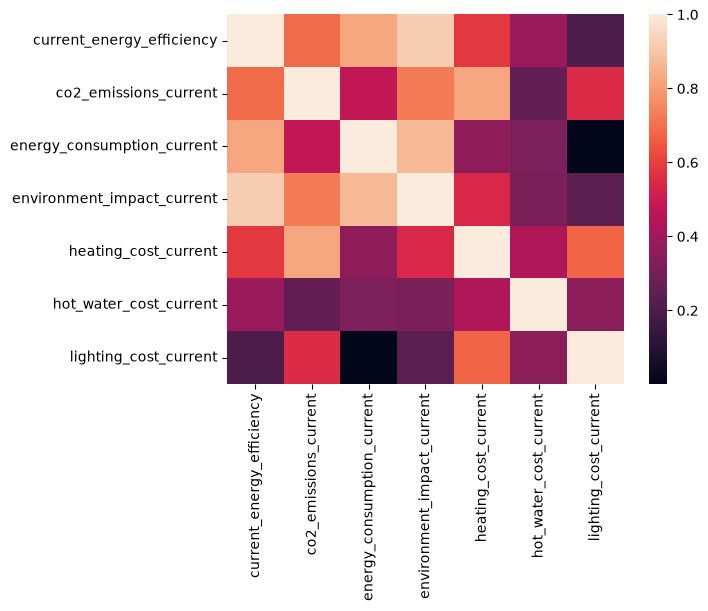

In [301]:
energy = ['current_energy_rating', 'current_energy_efficiency',
    'co2_emissions_current',
    'co2_emissions_potential',
    'energy_consumption_current',
    'energy_consumption_potential',
    'environment_impact_current',
    'environment_impact_potential',
    'heating_cost_current',
    'heating_cost_potential',
    'hot_water_cost_current',
    'hot_water_cost_potential',
    'lighting_cost_current',
    'lighting_cost_potential',
]

energy_current = ['current_energy_rating', 'current_energy_efficiency',
    'co2_emissions_current',
    'energy_consumption_current',
    'environment_impact_current',
    'heating_cost_current',
    'hot_water_cost_current',
    'lighting_cost_current',
]

print(df_raw[energy].corr(numeric_only=True))

sns.heatmap(abs(df_raw[energy_current].corr(numeric_only=True)))

- drop 'potential' columns except for 'potential_energy_efficiency' to still give an optional measure of room of improvement
- do costs correlate strongly with floor area?

In [302]:
energy_current_floor = ['total_floor_area', 'current_energy_rating', 'current_energy_efficiency',
    'co2_emissions_current',
    'energy_consumption_current',
    'environment_impact_current',
    'heating_cost_current',
    'hot_water_cost_current',
    'lighting_cost_current',
]
print(df_raw[energy_current_floor].corr(numeric_only=True))

                            total_floor_area  current_energy_efficiency  co2_emissions_current  energy_consumption_current  environment_impact_current  heating_cost_current  hot_water_cost_current  lighting_cost_current
total_floor_area                    1.000000                  -0.071085               0.633885                   -0.164188                   -0.092489              0.632758                0.102541               0.657935
current_energy_efficiency          -0.071085                   1.000000              -0.687953                   -0.820663                    0.920631             -0.584229               -0.384254              -0.201198
co2_emissions_current               0.633885                  -0.687953               1.000000                    0.474073                   -0.723212              0.823239                0.256051               0.551549
energy_consumption_current         -0.164188                  -0.820663               0.474073                    1.0000

- Keep heating_cost_current as its an intuitive running cost for a buyer
- drop co2_emissions_current (correlates 0.82 with heating), drop lighting_cost_current (small and correlated 0.66 with floor area), drop hot_water_cost_current (small)
- keep current_energy_efficiency and energy_consumption_current (size-independant)

In [303]:
df_raw['transaction_type'].value_counts(normalize=True)

transaction_type
Marketed sale                0.374339
Rental                       0.293784
New dwelling                 0.208336
None of the above            0.033579
ECO assessment               0.029901
Stock condition survey       0.026603
Non-marketed sale            0.009899
RHI application              0.007199
Assessment for Green Deal    0.007134
FiT application              0.006823
Following Green Deal         0.001136
Re-mortgaging                0.000654
Grant scheme                 0.000533
Non-grant scheme             0.000079
Name: proportion, dtype: float64

Useful information for matching with price database

In [304]:
df_raw['floor_height'].value_counts()

floor_height
2.400    23124
2.300    20653
2.410    13313
2.310    11563
2.390     9341
         ...  
1.480        1
2.961        1
2.249        1
2.623        1
2.251        1
Name: count, Length: 800, dtype: int64

Shows a variety of values, keep

In [305]:
df_raw.columns

Index(['certificate_number', 'address1', 'address2', 'address3', 'postcode', 'posttown', 'address', 'constituency', 'constituency_label', 'local_authority', 'local_authority_label', 'built_form', 'co2_emiss_curr_per_floor_area', 'co2_emissions_current', 'co2_emissions_potential', 'construction_age_band', 'current_energy_efficiency', 'current_energy_rating', 'energy_consumption_current', 'energy_consumption_potential', 'energy_tariff', 'environment_impact_current', 'environment_impact_potential', 'extension_count', 'fixed_lighting_outlets_count', 'flat_storey_count', 'flat_top_storey', 'floor_description', 'floor_energy_eff', 'floor_height', 'floor_level', 'glazed_area', 'glazed_type', 'heat_loss_corridor', 'heating_cost_current', 'heating_cost_potential', 'hot_water_cost_current', 'hot_water_cost_potential', 'hot_water_energy_eff', 'hot_water_env_eff', 'hotwater_description', 'inspection_date', 'lighting_cost_current', 'lighting_cost_potential', 'lighting_description',
       'lighting

In [306]:
full_column_list = ['certificate_number', 'address1', 'address2', 'address3', 'postcode',
       'posttown', 'address', 'constituency', 'constituency_label',
       'local_authority', 'local_authority_label', 'built_form',
       'co2_emiss_curr_per_floor_area', 'co2_emissions_current',
       'co2_emissions_potential', 'construction_age_band',
       'current_energy_efficiency', 'current_energy_rating',
       'energy_consumption_current', 'energy_consumption_potential',
       'energy_tariff', 'environment_impact_current',
       'environment_impact_potential', 'extension_count',
       'fixed_lighting_outlets_count', 'flat_storey_count', 'flat_top_storey',
       'floor_description', 'floor_energy_eff', 'floor_height', 'floor_level',
       'glazed_area', 'glazed_type', 'heat_loss_corridor',
       'heating_cost_current', 'heating_cost_potential',
       'hot_water_cost_current', 'hot_water_cost_potential',
       'hot_water_energy_eff', 'hot_water_env_eff', 'hotwater_description',
       'inspection_date', 'lighting_cost_current', 'lighting_cost_potential',
       'lighting_description', 'lighting_energy_eff', 'lighting_env_eff',
       'lodgement_date', 'lodgement_datetime', 'low_energy_lighting',
       'low_energy_fixed_lighting_outlets_count', 'main_fuel',
       'mainheat_description', 'mainheat_energy_eff', 'mainheat_env_eff',
       'mainheatc_energy_eff', 'mainheatc_env_eff', 'mainheatcont_description',
       'main_heating_controls', 'mains_gas_flag', 'mechanical_ventilation',
       'multi_glaze_proportion', 'number_habitable_rooms',
       'number_heated_rooms', 'number_open_fireplaces', 'photo_supply',
       'potential_energy_efficiency', 'potential_energy_rating',
       'property_type', 'report_type', 'roof_description', 'roof_energy_eff',
       'roof_env_eff', 'secondheat_description', 'sheating_energy_eff',
       'sheating_env_eff', 'solar_water_heating_flag', 'tenure',
       'total_floor_area', 'transaction_type', 'unheated_corridor_length',
       'walls_description', 'walls_energy_eff', 'walls_env_eff',
       'wind_turbine_count', 'windows_description', 'windows_energy_eff',
       'windows_env_eff', 'floor_env_eff', 'region', 'country', 'uprn',
       'uprn_source']

columns_to_keep = [
    'certificate_number', 'address1', 'address2', 'address3', 'postcode',
    'posttown', 'address', 'local_authority', 'local_authority_label',
    'built_form', 'construction_age_band', 'current_energy_efficiency',
    'current_energy_rating', 'energy_consumption_current', 'extension_count',
    'flat_storey_count', 'floor_height', 'heating_cost_current',
    'inspection_date', 'lodgement_date', 'number_habitable_rooms',
    'number_heated_rooms', 'potential_energy_efficiency', 'property_type',
    'tenure', 'total_floor_area', 'transaction_type', 'uprn', 'uprn_source'
]

columns_to_drop = [
    'constituency', 'constituency_label', 'co2_emiss_curr_per_floor_area',
    'co2_emissions_current', 'co2_emissions_potential',
    'energy_consumption_potential', 'energy_tariff',
    'environment_impact_current', 'environment_impact_potential',
    'fixed_lighting_outlets_count', 'flat_top_storey', 'floor_description',
    'floor_energy_eff', 'floor_level', 'glazed_area', 'glazed_type',
    'heat_loss_corridor', 'heating_cost_potential', 'hot_water_cost_current',
    'hot_water_cost_potential', 'hot_water_energy_eff', 'hot_water_env_eff',
    'hotwater_description', 'lighting_cost_current', 'lighting_cost_potential',
    'lighting_description', 'lighting_energy_eff', 'lighting_env_eff',
    'lodgement_datetime', 'low_energy_lighting',
    'low_energy_fixed_lighting_outlets_count', 'main_fuel',
    'mainheat_description', 'mainheat_energy_eff', 'mainheat_env_eff',
    'mainheatc_energy_eff', 'mainheatc_env_eff', 'mainheatcont_description',
    'main_heating_controls', 'mains_gas_flag', 'mechanical_ventilation',
    'multi_glaze_proportion', 'number_open_fireplaces', 'photo_supply',
    'potential_energy_rating', 'report_type', 'roof_description',
    'roof_energy_eff', 'roof_env_eff', 'secondheat_description',
    'sheating_energy_eff', 'sheating_env_eff', 'solar_water_heating_flag',
    'unheated_corridor_length', 'walls_description', 'walls_energy_eff',
    'walls_env_eff', 'wind_turbine_count', 'windows_description',
    'windows_energy_eff', 'windows_env_eff', 'floor_env_eff', 'region',
    'country'
]

full_set = set(full_column_list)
keep_set = set(columns_to_keep)
drop_set = set(columns_to_drop)


print("Duplicates in full list:", len(full_column_list) - len(full_set))
print("Duplicates in columns_to_keep:", len(columns_to_keep) - len(keep_set))
print("Duplicates in columns_to_drop:", len(columns_to_drop) - len(drop_set))

overlap = keep_set.intersection(drop_set)
print("Columns in BOTH keep & drop:", overlap)

missing = full_set - (keep_set | drop_set)
print("Columns missing from both lists:", missing)

extra = (keep_set | drop_set) - full_set
print("Unexpected columns (not in full list):", extra)

Duplicates in full list: 0
Duplicates in columns_to_keep: 0
Duplicates in columns_to_drop: 0
Columns in BOTH keep & drop: set()
Columns missing from both lists: set()
Unexpected columns (not in full list): set()


In [307]:
df = df_raw[columns_to_keep].copy()

df.head()

df[['number_habitable_rooms', 'number_heated_rooms']].corr()
(df.shape[0] - (df['number_habitable_rooms'] == df['number_heated_rooms']).sum()) / df.shape[0]

np.float64(0.2528071685782258)

Is heated rooms redundant with habitable rooms?
No there are 25% of cases where they are not equal

In [308]:
(df['number_heated_rooms'] > df['number_habitable_rooms']).sum()

np.int64(1)

Heated rooms only exceeds habitable in one case

### Data audit on kept columns

Drop 4 rows with out-of-scope local_authority

In [309]:
df = df[df['local_authority'] != 'E07000221']

df['local_authority'].value_counts()

local_authority
E07000177    47544
E07000178    45721
E07000180    45639
E07000179    42271
E07000181    34875
Name: count, dtype: int64

In [310]:
df.dtypes

certificate_number                 str
address1                           str
address2                           str
address3                           str
postcode                           str
posttown                           str
address                            str
local_authority                    str
local_authority_label              str
built_form                         str
construction_age_band              str
current_energy_efficiency        int64
current_energy_rating              str
energy_consumption_current       int64
extension_count                float64
flat_storey_count              float64
floor_height                   float64
heating_cost_current             int64
inspection_date                    str
lodgement_date                     str
number_habitable_rooms         float64
number_heated_rooms            float64
potential_energy_efficiency      int64
property_type                      str
tenure                             str
total_floor_area         

#### Core numeric features

In [311]:
print(df['total_floor_area'].describe())

print(f"There are {(df['total_floor_area'] < 10).sum()} records with < 10 sqm floor areas and {(df['total_floor_area'] > 2000).sum()} with > 2000 sqm")

print(df[['address1', 'number_habitable_rooms', 'total_floor_area', 'property_type']][df['total_floor_area'] < 10].sort_values(by = 'number_habitable_rooms', ascending = False))

count    216050.000000
mean         97.073751
std          63.362160
min           3.000000
25%          64.000000
50%          83.000000
75%         111.000000
max        5133.000000
Name: total_floor_area, dtype: float64
There are 27 records with < 10 sqm floor areas and 8 with > 2000 sqm
                                       address1  number_habitable_rooms  total_floor_area property_type
26042                            8 Colerne Road                     4.0                 8         House
14600                           2, Queens Court                     3.0                 9          Flat
114080                       33, King James Way                     3.0                 6          Flat
140466                         24 SPRING STREET                     3.0                 9          Flat
151753                       6a, Bradstocks Way                     2.0                 7    Maisonette
51769                            24, Manor Road                     2.0             

In [312]:
df['area_per_hab_room'] = df['total_floor_area'] / df['number_habitable_rooms']
print(df[['certificate_number', 'address1', 'number_habitable_rooms', 'total_floor_area', 'area_per_hab_room', 'property_type']][df['total_floor_area'] > 2000].sort_values(by = 'number_habitable_rooms', ascending = False))

print(df['area_per_hab_room'].describe())

print(f"\nThere are {df['total_floor_area'].isna().sum()} null values")

              certificate_number              address1  number_habitable_rooms  total_floor_area  area_per_hab_room property_type
19372   9360-2814-0290-2202-6351        Cornbury House                    39.0              2894          74.205128         House
136900  8206-7322-4290-4245-7906       The Old Laundry                     7.0              2860         408.571429         House
200408  0552-3041-5201-3644-6204           3 Ash Grove                     4.0              2252         563.000000         House
184990  1032-5920-2209-0815-0202     12 Easington Road                     4.0              4836        1209.000000         House
123810  0044-2876-6518-9608-3961  53, Catherine Street                     3.0              2353         784.333333         House
127446  8171-6324-5580-7887-6996     16, Hill Top Road                     3.0              2043         681.000000         House
41987   3434-1132-3000-0328-7226          Tymure House                     NaN            

<Axes: xlabel='total_floor_area', ylabel='Count'>

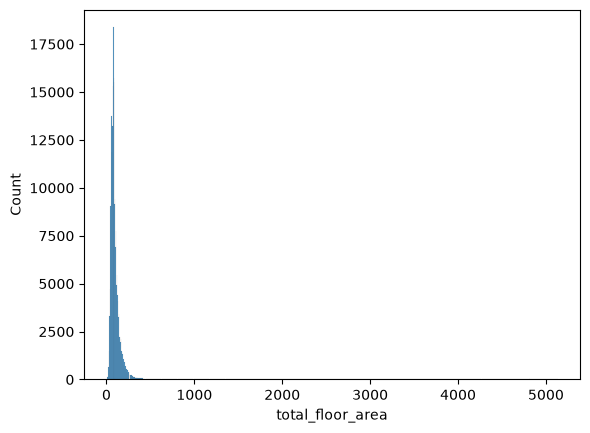

In [313]:
sns.histplot(df['total_floor_area'])

- total_floor_area
    - mean = 97, median = 83, min = 3, max = 5133, 75% = 111
    - There are 27 records with < 10 sqm floor areas and 8 with > 2000 sqm
        - 19 records are flats in the same building (7 or 9 sqm) with 1 habitable room
        - 1 is a room of 3 sqm
        - 7 are records with 2-4 habitable rooms but 5-9 sqm floor area (each room <= 3 sqm)
            - 3 are house or maisonette, size is too small to be real, exclude
            - 4 are flats.
        - National space standards put a bedroom at 6.5-7.5sqm. *Proposed: Exclude these 7 records with multiple rooms and < 9 sqm. Exclude the record with 3 sqm. Keep the 19 records that are 1 room flats (7-9 sqm).*
    - There are 8 records with > 2000 sqm
        - 2 have NaN habitable rooms
        - 5 have 3 - 7 habitable rooms (implausible)
        - 1 has 39 habitable rooms (plausible)
        - perhaps average floor area per habitable room would be a good measure. These have up to 1209 sqm per room.
            - On full dataset it ranges from 0.8 sqm/room to 1209 sqm/room, median 20 sqm, mean 21 sqm.
        - *Proposed: Exclude the 7 records with >2000 sqm and <= 7 rooms (8206-7322-4290-4245-7906, 0552-3041-5201-3644-6204, 1032-5920-2209-0815-0202, 0044-2876-6518-9608-3961, 8171-6324-5580-7887-6996, 3434-1132-3000-0328-7226, 5135-0635-7000-0689-9206)*
    - Small areas will have a larger effect on £ per sqm calculations later, so important to clean.

        

In [314]:
col = ['number_habitable_rooms', 'number_heated_rooms', 'extension_count', 'flat_storey_count', 'floor_height']
for i in col:
    print(f"The range of values for {i} is {df[i].min()} to {df[i].max()}, with median of {df[i].median()}")
    print(f"There are {df[i].isna().sum()} null values\n")


print((df['floor_height'] > 5).sum())
print(df[df['floor_height'] > 5].sort_values(by='floor_height', ascending=False).head(10))

The range of values for number_habitable_rooms is 1.0 to 81.0, with median of 4.0
There are 49419 null values

The range of values for number_heated_rooms is 0.0 to 55.0, with median of 4.0
There are 49419 null values

The range of values for extension_count is 0.0 to 4.0, with median of 0.0
There are 49419 null values

The range of values for flat_storey_count is 1.0 to 9.0, with median of 2.0
There are 5016 null values

The range of values for floor_height is 0.0 to 8.87, with median of 2.38
There are 1615 null values

53
              certificate_number                address1              address2           address3  postcode          posttown                                          address local_authority local_authority_label            built_form            construction_age_band  current_energy_efficiency current_energy_rating  energy_consumption_current  extension_count  flat_storey_count  floor_height  heating_cost_current inspection_date lodgement_date  number_habitable_room

In [315]:

print(f"There are {df[df['number_heated_rooms'] == 0].shape[0]} records with 0 heated rooms")
print(f"There are {df[df['floor_height'] < 1.5].shape[0]} records with floor height < 1.5m. Including {df[df['floor_height'] < 1].shape[0]} records with floor height < 1m.")

There are 338 records with 0 heated rooms
There are 2516 records with floor height < 1.5m. Including 98 records with floor height < 1m.


In [316]:
print(pd.concat(
    [df['transaction_type'].value_counts(normalize=True), 
    df[df['number_habitable_rooms'].isna()]['transaction_type'].value_counts(normalize=True)], axis=1, keys=['full_set_%', 'null_rooms_%']))

print(df[df['number_habitable_rooms'].isna()].head())

                           full_set_%  null_rooms_%
transaction_type                                   
Marketed sale                0.374332      0.053077
Rental                       0.293785      0.000992
New dwelling                 0.208340      0.908820
None of the above            0.033580      0.035836
ECO assessment               0.029901           NaN
Stock condition survey       0.026603           NaN
Non-marketed sale            0.009899      0.000830
RHI application              0.007199           NaN
Assessment for Green Deal    0.007134      0.000020
FiT application              0.006824      0.000425
Following Green Deal         0.001136           NaN
Re-mortgaging                0.000654           NaN
Grant scheme                 0.000533           NaN
Non-grant scheme             0.000079           NaN
          certificate_number                  address1         address2 address3  postcode posttown                                 address local_authority local_author

In [317]:
print(f"Flat storey count is null:")
print(pd.concat([df['property_type'].value_counts(normalize=True), df[df['flat_storey_count'].isna()]['property_type'].value_counts(normalize=True)], axis=1, keys=['full_set_%', 'null_set_%']))


print(f"\nFloor height is null:")
print(pd.concat([df['property_type'].value_counts(normalize=True), df[df['floor_height'].isna()]['property_type'].value_counts(normalize=True)], axis=1, keys=['full_set_%', 'null_set_%']))

Flat storey count is null:
               full_set_%  null_set_%
property_type                        
House            0.700703    0.611443
Flat             0.207098    0.324163
Bungalow         0.071490    0.061802
Maisonette       0.019491    0.002193
Park home        0.001217    0.000399

Floor height is null:
               full_set_%  null_set_%
property_type                        
House            0.700703    0.004954
Flat             0.207098    0.993808
Bungalow         0.071490         NaN
Maisonette       0.019491    0.001238
Park home        0.001217         NaN


In [318]:
print(f"Percentage of New dwelling records with null 'number_heated_rooms': {100 * (df[df['transaction_type'] == 'New dwelling']['number_heated_rooms'].isna()).sum() / df[df['transaction_type'] == 'New dwelling'].shape[0]}%")

Percentage of New dwelling records with null 'number_heated_rooms': 100.0%


In [319]:
print(df.groupby('property_type')['flat_storey_count'].agg('median'))
print(df[df['flat_storey_count'] > 3]['property_type'].value_counts())
print(df[df['flat_storey_count'] > 4]['property_type'].value_counts())

property_type
Bungalow      1.0
Flat          1.0
House         2.0
Maisonette    1.0
Park home     1.0
Name: flat_storey_count, dtype: float64
property_type
House       428
Bungalow      1
Flat          1
Name: count, dtype: int64
property_type
House    11
Name: count, dtype: int64


- 'number_habitable_rooms', 'number_heated_rooms', 'extension_count', 'flat_storey_count', 'floor_height'
    - The range of values for number_habitable_rooms is 1.0 to 81.0, with median of 4.0
    - The range of values for number_heated_rooms is 0.0 to 55.0, with median of 4.0
          - Max room counts will need floor size to audit (or my sqm/room calculation), but 81 or 55 rooms is high
          - Zero heated rooms is implausible (338 records). *Proposed: Treat records with 0 heated rooms as value is missing.*
    - The range of values for 'extension_count' is 0.0 to 4.0, with median of 0.0
        - Reasonable
    - The range of values for 'flat_storey_count' is 1.0 to 9.0, with median of 2.0
        - 430 records with 'flat_storey_count' > 3 (428 Houses). 11 records with 'flat_storey_count' > 4 (11 Houses, up to 9 storeys). 
        - Reading online suggests this should be a measure of the size of a block of flats, havent found a good source for column definitions. *Proposed: Definition unclear, not a reliable feature unless clarified (drop)*
    - The range of values for 'floor_height' is 0.0 to 8.87, with median of 2.38
        - 53 records with 'floor height' > 5m. Many are built <1900. Believable for say converted churches or houses with mezzanine?
        - There are 2516 records with 'floor height' < 1.5m. Including 98 records with 'floor height' < 1m. *Proposed: Treat records with floor height < 1.5m as missing.*
    - Nulls
        - There are 49419 records with null for all of 'number_habitable_rooms', 'number_heated_rooms', 'extension_count'
        - These are disproportionately new dwellings (91% vs 21% new dwellings in wider sample)
        - All New dwelling records ('transaction_type') have null 'number_heated_rooms'. This is consistent with a different type of assessment for new builds.
        - 'flat_storey_count' is null in 5016 cases
            - Distribution of 'property_type' (e.g. flat vs house etc) slightly skewed toward flats (21 vs 32%)
        - 'floor_height'
            - 1615 null values. 99% are for Flats where the 'floor_height' is likely to be very standardised. *Proposed: Fill flat nulls with the average flat floor_height.*
  

Duplicate certificates

In [320]:
print(df.shape[0] - df['certificate_number'].nunique())
print(df['certificate_number'].isna().sum())
print(df.duplicated(subset='certificate_number').sum())

print(df.shape[0] - df['uprn'].nunique())
print(df['uprn'].isna().sum())
print(df.groupby('uprn')['certificate_number'].agg('count').sort_values(ascending=False))
print(df.duplicated(subset='uprn').sum())

0
0
0
26777
1318
uprn
1.000276e+10    50
1.002418e+10    39
1.001188e+10    32
1.001209e+11    20
1.003301e+10    18
                ..
1.000219e+10     1
1.000219e+10     1
1.000219e+10     1
1.000219e+10     1
1.000219e+10     1
Name: certificate_number, Length: 189273, dtype: int64
26776


- 'certificate_number' is unique with no missing values. None flagged as duplicated
- each 'uprn' has up to 50 'certificate_number' associated with it. 26776 flagged as duplicated
- 

In [321]:
categorical = ['property_type', 'built_form', 'construction_age_band', 'tenure', 'transaction_type', 'current_energy_rating', 'uprn_source']

for i in categorical:
    print(f"{i} has {df[i].nunique()} unique values.")
    print(df[i].value_counts())

property_type has 5 unique values.
property_type
House         151382
Flat           44742
Bungalow       15445
Maisonette      4211
Park home        263
Name: count, dtype: int64
built_form has 7 unique values.
built_form
Semi-Detached           73124
Detached                58752
Mid-Terrace             45183
End-Terrace             30571
Enclosed End-Terrace     2913
Enclosed Mid-Terrace     1696
Not Recorded             1305
Name: count, dtype: int64
construction_age_band has 67 unique values.
construction_age_band
England and Wales: 1950-1966      31860
England and Wales: 1967-1975      23161
England and Wales: before 1900    17109
England and Wales: 1983-1990      15607
England and Wales: 1930-1949      14232
                                  ...  
1976                                  1
1933                                  1
2104                                  1
1975                                  1
1600                                  1
Name: count, Length: 67, dtype: int

In [322]:
df.groupby('construction_age_band')['certificate_number'].count().sort_values(ascending=False).head(50)

construction_age_band
England and Wales: 1950-1966       31860
England and Wales: 1967-1975       23161
England and Wales: before 1900     17109
England and Wales: 1983-1990       15607
England and Wales: 1930-1949       14232
England and Wales: 1900-1929       13539
England and Wales: 1976-1982       12285
England and Wales: 1996-2002       11892
England and Wales: 1991-1995       10027
England and Wales: 2003-2006        8400
2018                                6440
England and Wales: 2007-2011        5831
2020                                5442
2019                                5377
2016                                4528
2022                                4502
2021                                4456
2017                                4144
2015                                3996
England and Wales: 2012 onwards     3150
2014                                2882
2023                                2526
2024                                1641
2013                               

| Column | Unique values | Top values | Placeholders / anomalies | Proposed treatment |
|---|---|---|---|---|
| `property_type` | 5|House, Flat |'Not Recorded' (1305, 0.6%) |None |
| `built_form` | 7|Semi-Detached, Detached | | |
| `construction_age_band` | 67|England and Wales: 1950-1966, England and Wales: 1967-1975 |Mixture of bands and specific years. 201 as year|Convert single years into bands and exclude 201 |
| `tenure` |4 |owner-occupied, rented (private) | | |
| `transaction_type` |14 |Marketed sale, Rental  |Contains 'None of the above' |Likely none needed as less common types may not correspond to a sale |
| `current_energy_rating` | 7|C, D, B | | |
| `uprn_source` |2 |Energy Assessor, Address Matched  | | |

In [323]:
print(df['inspection_date'].describe())
df['lodgement_date'] = df['lodgement_date'].astype('datetime64[ns]')
print(df['lodgement_date'].describe())

count         216050
unique          3859
top       2022-08-22
freq             276
Name: inspection_date, dtype: object
count                           216050
mean     2020-09-17 15:37:24.980328448
min                2015-01-02 00:00:00
25%                2018-04-11 00:00:00
50%                2020-11-04 00:00:00
75%                2023-04-24 00:00:00
max                2025-12-31 00:00:00
Name: lodgement_date, dtype: object


In [324]:
df['inspection_date'] = df['inspection_date'].astype('datetime64[ns]') 
print((df['inspection_date'] < '2015-01-01').sum())
print(df[df['inspection_date'] < '2015-01-01'].head())
print((df['inspection_date'] > '2025-12-31').sum())
print(df['lodgement_date'].isna().sum())
print(df['inspection_date'].isna().sum())

468
            certificate_number                  address1               address2 address3  postcode posttown                                            address local_authority local_authority_label built_form construction_age_band  current_energy_efficiency current_energy_rating  energy_consumption_current  extension_count  flat_storey_count  floor_height  heating_cost_current inspection_date lodgement_date  number_habitable_rooms  number_heated_rooms  potential_energy_efficiency property_type          tenure  total_floor_area transaction_type          uprn      uprn_source  area_per_hab_room
1178  0628-2027-7313-3444-3920           21, Linnet Road               Bodicote      NaN  OX15 4FY  BANBURY                          21, Linnet Road, Bodicote       E07000177              Cherwell        NaN                  2015                         82                     B                         108              NaN                NaN           NaN                   232      2014-07-02   

- 'inspection_date' & 'lodgement_date'
    - format: YYYY-MM-DD
    - 'lodgement_date' fully within intended 2015-01-01 - 2015-12-31 limits
    - 468 records where the 'inspection_date' falls in 2014 but 'lodgement_date' is in 2015
    - No 'inspection_date' after 2025-12-31
    - No 'inspection_date' or 'lodgement_date' records are null

In [325]:
from pathlib import Path
folder = Path('../data/raw')
file_gen = folder.glob('ppd_data*.csv')
pp = pd.concat([pd.read_csv(f) for f in file_gen])

In [326]:
pp_postcode = set(pp['postcode'])
epc_postcode = set(df['postcode'])

matched = 100* len(epc_postcode.intersection(pp_postcode)) / len(pp_postcode)
print(f"{matched:.1f}")

94.7


- 'postcode' matching pre-check
    - Set of 'postcode' compared with price paid 'postcode' set. Found that 94.7% of the price paid postcodes are found in the EPC database.

- Can confirm 'address' is a combination of 'address1', 'address2' and 'address3'

In [327]:
df[['current_energy_rating', 'current_energy_efficiency']].head()

bins = [0, 20, 38, 54, 68, 80, 91, 200]
bands = ['G', 'F', 'E', 'D', 'C', 'B', 'A']
df['calc_band'] = pd.cut(df['current_energy_efficiency'], bins=bins, labels=bands, include_lowest=True)

print(pd.concat([df['current_energy_rating'].value_counts(), df['calc_band'].value_counts()], axis=1))
print(f" There is a {100 * (df['current_energy_rating'] == df['calc_band']).sum() / df.shape[0]:.2f}% match between given and calculated energy_rating")

print(df['current_energy_efficiency'].describe())
print(((df['current_energy_efficiency'] > 110) & (df['energy_consumption_current'] > 0)).sum())
print(df[(df['current_energy_efficiency'] > 110) & (df['energy_consumption_current'] > 0)])

   count  count
C  73023  73023
D  64114  64114
B  47028  47028
E  22392  22392
F   5637   5637
A   2514   2514
G   1342   1342
 There is a 100.00% match between given and calculated energy_rating
count    216050.000000
mean         68.695788
std          13.908456
min           1.000000
25%          62.000000
50%          70.000000
75%          79.000000
max         156.000000
Name: current_energy_efficiency, dtype: float64
6
              certificate_number               address1    address2 address3  postcode    posttown                        address local_authority local_authority_label     built_form         construction_age_band  current_energy_efficiency current_energy_rating  energy_consumption_current  extension_count  flat_storey_count  floor_height  heating_cost_current inspection_date lodgement_date  number_habitable_rooms  number_heated_rooms  potential_energy_efficiency property_type          tenure  total_floor_area   transaction_type          uprn      uprn_source  are

- Checking 'current_energy_rating' against 'current_energy_efficiency'
    - Calculated energy ratings from efficiency. Perfect agreement between.
    - Worth noting that the efficiency can go over 100 if a property generates more energy (ultra-modern properties with renewable energy generation) than it uses. There are 417 records with efficiency > 100 inc 41 with efficiency > 110.
    - There are 6 records with an efficiencies over 110 but with positive 'energy_consumption_current'. These are edge cases, unusual but plausible as they may still use a large amount of energy in winter months. Two have energy_consumption_current >200 and are Maisonette/Flat which flags them as likely errors. *Proposed: Exclude 2051-7735-3040-1307-9975 and 0061-1212-2504-8687-0900*